# Attention: If you run the notebook, please skip the “Train baseline CNN” cell, otherwise the baseline results may change due to randomness in training.

# Explainable Medical Image Triage Using Transfer Learning

##1. Data Loading

This section loads the PneumoniaMNIST dataset, visualizes sample images, and summarizes the class distribution.

In [ ]:
# Install packages
!pip -q install medmnist torch torchvision scikit-learn matplotlib

In [ ]:
# Import libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import medmnist
from medmnist import INFO

# Reproducibility setup

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [ ]:
# Choose MedMNIST dataset

DATA_FLAG = "pneumoniamnist"

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

print("Dataset:", DATA_FLAG)
print("Task:", info["task"])
print("Number of classes:", len(info["label"]))
print("Labels:", info["label"])
print("Image channels:", info["n_channels"])

Dataset: pneumoniamnist
Task: binary-class
Number of classes: 2
Labels: {'0': 'normal', '1': 'pneumonia'}
Image channels: 1


In [ ]:
# Define transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Load train / val / test datasets

train_dataset = DataClass(
    split="train",
    transform=train_transform,
    download=True,
    as_rgb=True
)

val_dataset = DataClass(
    split="val",
    transform=eval_transform,
    download=True,
    as_rgb=True
)

test_dataset = DataClass(
    split="test",
    transform=eval_transform,
    download=True,
    as_rgb=True
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 4708
Validation size: 524
Test size: 624


In [ ]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Example labels:", labels[:10].squeeze().tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32, 1])
Example labels: [1, 0, 1, 0, 0, 1, 0, 1, 1, 1]


In [ ]:
# Check class distribution

label_names = {int(k): v for k, v in info["label"].items()}

def show_class_distribution(dataset, split_name):
    labels = dataset.labels.squeeze()
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{split_name} class distribution:")
    for cls, count in zip(unique, counts):
        print(f"Class {cls} ({label_names[int(cls)]}): {count}")

show_class_distribution(train_dataset, "Train")
show_class_distribution(val_dataset, "Validation")
show_class_distribution(test_dataset, "Test")


Train class distribution:
Class 0 (normal): 1214
Class 1 (pneumonia): 3494

Validation class distribution:
Class 0 (normal): 135
Class 1 (pneumonia): 389

Test class distribution:
Class 0 (normal): 234
Class 1 (pneumonia): 390


In [ ]:
# Class distribution table

def get_class_distribution(dataset, split_name):
    labels = dataset.labels.squeeze()
    unique, counts = np.unique(labels, return_counts=True)

    rows = []
    for cls, count in zip(unique, counts):
        rows.append({
            "Split": split_name,
            "Class ID": int(cls),
            "Class Name": label_names[int(cls)],
            "Count": int(count),
            "Percentage": round(count / len(dataset) * 100, 2)
        })
    return rows

distribution_rows = []
distribution_rows.extend(get_class_distribution(train_dataset, "Train"))
distribution_rows.extend(get_class_distribution(val_dataset, "Validation"))
distribution_rows.extend(get_class_distribution(test_dataset, "Test"))

class_distribution_df = pd.DataFrame(distribution_rows)
class_distribution_df

,Split,Class ID,Class Name,Count,Percentage
0,Train,0,normal,1214,25.79
1,Train,1,pneumonia,3494,74.21
2,Validation,0,normal,135,25.76
3,Validation,1,pneumonia,389,74.24
4,Test,0,normal,234,37.50
5,Test,1,pneumonia,390,62.50


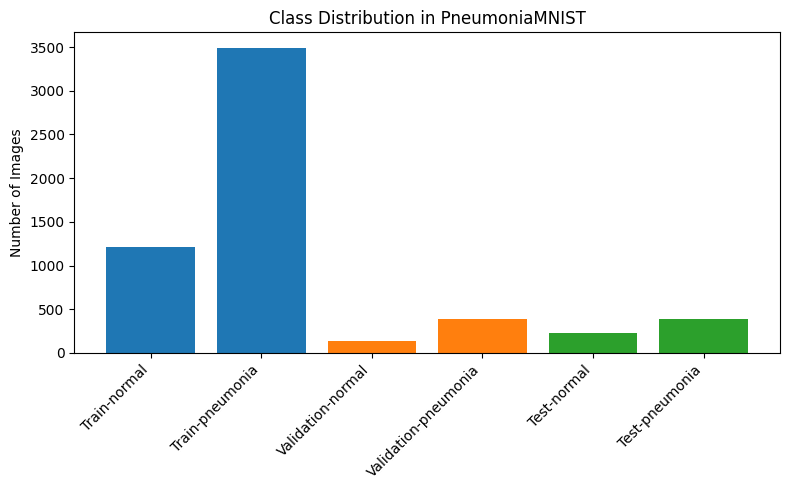

In [ ]:
# Plot class distribution

plt.figure(figsize=(8, 5))

for split_name, dataset in [
    ("Train", train_dataset),
    ("Validation", val_dataset),
    ("Test", test_dataset)
]:
    labels = dataset.labels.squeeze()
    unique, counts = np.unique(labels, return_counts=True)
    plt.bar(
        [f"{split_name}-{label_names[int(cls)]}" for cls in unique],
        counts
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.title("Class Distribution in PneumoniaMNIST")
plt.tight_layout()
plt.show()

PneumoniaMNIST is a binary medical image classification dataset with two classes: normal and pneumonia. The dataset is split into training, validation, and test sets. Since the class distribution is imbalanced, we report not only accuracy but also precision, recall, F1-score, false positives, and false negatives.

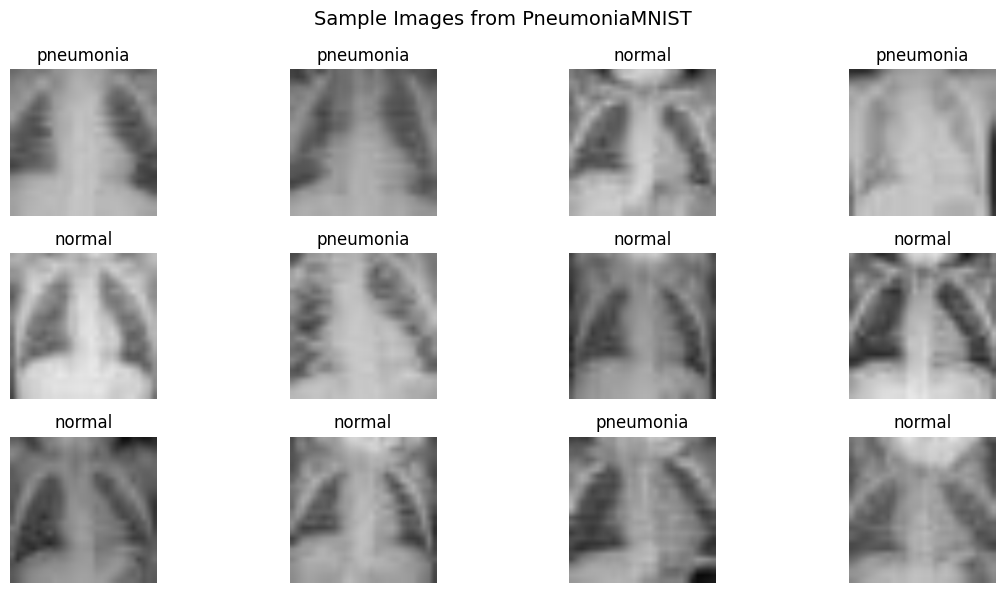

In [ ]:
# Display sample images

# Use a non-normalized transform for visualization.

viz_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

viz_dataset = DataClass(
    split="train",
    transform=viz_transform,
    download=True,
    as_rgb=True
)

viz_loader = DataLoader(viz_dataset, batch_size=12, shuffle=True)
viz_images, viz_labels = next(iter(viz_loader))

plt.figure(figsize=(12, 6))

for i in range(12):
    img = viz_images[i].permute(1, 2, 0).numpy()
    label_id = int(viz_labels[i].item())

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label_names[label_id])
    plt.axis("off")

plt.suptitle("Sample Images from PneumoniaMNIST", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Baseline CNN

This section trains a baseline CNN from scratch. This baseline model will later be compared with transfer learning models such as ResNet18 or EfficientNet-B0

In [ ]:
import torch.nn as nn
import torch.optim as optim
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
# Baseline CNN model

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN(num_classes=2).to(device)
print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [ ]:
# Compute class weights for imbalanced data

train_labels = train_dataset.labels.squeeze()
unique_classes, class_counts = np.unique(train_labels, return_counts=True)

num_classes = len(unique_classes)
total_samples = len(train_labels)

class_weights = []
for cls in range(num_classes):
    count = class_counts[unique_classes.tolist().index(cls)]
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

Class weights: tensor([1.9390, 0.6737], device='cuda:0')


In [ ]:
# Training and evaluation functions

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    metrics = {
        "loss": epoch_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "confusion_matrix": confusion_matrix(all_labels, all_preds),
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

    return metrics

# Please skip this “Train baseline CNN” cell! DO NOT RERUN!

In [ ]:
# Train baseline CNN

NUM_EPOCHS = 5

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = -1
best_model_state = None
best_epoch = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        baseline_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate_model(
        baseline_model,
        val_loader,
        criterion,
        device
    )

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])

    if val_metrics["f1"] > best_val_f1:
       best_val_f1 = val_metrics["f1"]
       best_model_state = copy.deepcopy(baseline_model.state_dict())
       best_epoch = epoch + 1


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | Val F1: {val_metrics['f1']:.4f}"
    )

# Load best validation model
baseline_model.load_state_dict(best_model_state)
print(f"Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")

Epoch [1/5] Train Loss: 0.3284 | Train Acc: 0.8602 | Val Loss: 0.7204 | Val Acc: 0.5344 | Val Precision: 0.9932 | Val Recall: 0.3753 | Val F1: 0.5448
Epoch [2/5] Train Loss: 0.2684 | Train Acc: 0.8842 | Val Loss: 0.2948 | Val Acc: 0.8397 | Val Precision: 0.9904 | Val Recall: 0.7918 | Val F1: 0.8800
Epoch [3/5] Train Loss: 0.2422 | Train Acc: 0.8970 | Val Loss: 0.2372 | Val Acc: 0.8760 | Val Precision: 0.9765 | Val Recall: 0.8535 | Val F1: 0.9108
Epoch [4/5] Train Loss: 0.2349 | Train Acc: 0.9057 | Val Loss: 0.2841 | Val Acc: 0.8511 | Val Precision: 0.9698 | Val Recall: 0.8252 | Val F1: 0.8917
Epoch [5/5] Train Loss: 0.2233 | Train Acc: 0.9093 | Val Loss: 0.2747 | Val Acc: 0.9198 | Val Precision: 0.9221 | Val Recall: 0.9743 | Val F1: 0.9475
Best validation F1: 0.9475 at epoch 5


In [ ]:
# Convert training history to DataFrame

history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.328402,0.860238,0.720418,0.534351,0.993197,0.375321,0.544776
1,2,0.268435,0.884240,0.294794,0.839695,0.990354,0.791774,0.880000
2,3,0.242186,0.896984,0.237192,0.875954,0.976471,0.853470,0.910837
3,4,0.234889,0.905692,0.284091,0.851145,0.969789,0.825193,0.891667
4,5,0.223276,0.909303,0.274729,0.919847,0.922141,0.974293,0.947500


In [ ]:
# Evaluate the best baseline CNN on the test set

test_metrics = evaluate_model(
    baseline_model,
    test_loader,
    criterion,
    device
)

print("Baseline CNN Test Results")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall / Sensitivity: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")

print("\nConfusion Matrix:")
print(test_metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=[label_names[0], label_names[1]],
    zero_division=0
))

Baseline CNN Test Results
Test Loss: 0.6930
Accuracy: 0.8077
Precision: 0.7722
Recall / Sensitivity: 0.9821
F1-score: 0.8646

Confusion Matrix:
[[121 113]
 [  7 383]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.95      0.52      0.67       234
   pneumonia       0.77      0.98      0.86       390

    accuracy                           0.81       624
   macro avg       0.86      0.75      0.77       624
weighted avg       0.84      0.81      0.79       624



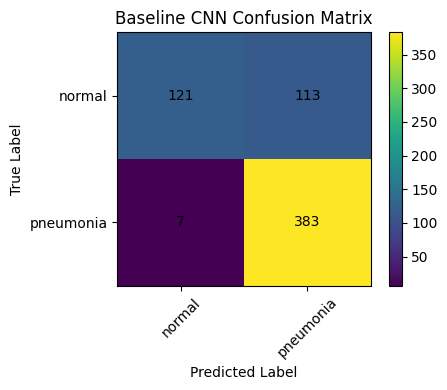

In [ ]:
# Plot confusion matrix for baseline CNN

cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Baseline CNN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, [label_names[i] for i in range(len(label_names))], rotation=45)
plt.yticks(tick_marks, [label_names[i] for i in range(len(label_names))])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

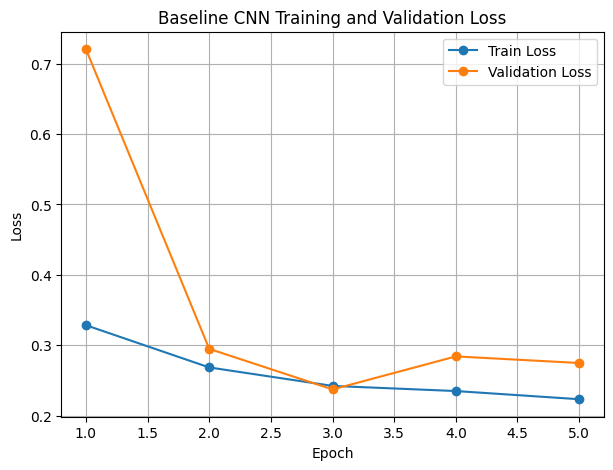

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

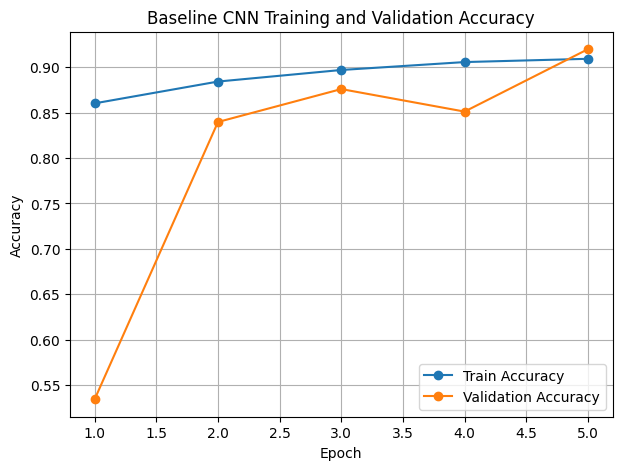

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save baseline CNN results

baseline_results = pd.DataFrame([{
    "Model": "Baseline CNN",
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall/Sensitivity": test_metrics["recall"],
    "F1-score": test_metrics["f1"],
    "False Positives": int(test_metrics["confusion_matrix"][0, 1]),
    "False Negatives": int(test_metrics["confusion_matrix"][1, 0])
}])

baseline_results.to_csv("baseline_cnn_results.csv", index=False)
baseline_results

,Model,Accuracy,Precision,Recall/Sensitivity,F1-score,False Positives,False Negatives
0,Baseline CNN,0.807692,0.772177,0.982051,0.86456,113,7


In [ ]:
# Save baseline CNN model checkpoint

checkpoint = {
    "model_name": "BaselineCNN",
    "model_state_dict": baseline_model.state_dict(),
    "image_size": IMAGE_SIZE,
    "label_names": label_names,
    "test_metrics": {
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "confusion_matrix": test_metrics["confusion_matrix"].tolist()
    }
}

torch.save(checkpoint, "baseline_cnn_pneumoniamnist.pth")
print("Saved baseline model checkpoint: baseline_cnn_pneumoniamnist.pth")

Saved baseline model checkpoint: baseline_cnn_pneumoniamnist.pth


The baseline CNN reached its strongest validation F1-score at epoch 5, while the lowest validation loss occurred at epoch 3. This suggests that validation performance fluctuated across epochs, but the model had largely converged within five epochs. Since the final model selection was based on validation F1-score, the epoch 5 checkpoint was selected for test evaluation.

On the test set, the baseline CNN achieved high recall/sensitivity but lower precision. This means the model missed very few pneumonia cases, which is useful for a triage setting, but it also produced many false positives, increasing the number of normal images flagged for review. Therefore, this baseline is useful for comparison, but the transfer learning model should aim to improve the precision-recall balance and reduce unnecessary false alerts.